In [14]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class LensDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
            self.df = df.reset_index(drop=True)
            self.image_dir = image_dir
            self.transform = transform

    def __len__(self):
            return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.load(os.path.join(self.image_dir, row['filename']))
        
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        # ResNet expects 3 channels — repeat single channel 3 times
        img = np.stack([img, img, img], axis=0).astype(np.float32)
        
        label = torch.tensor(row['label'], dtype=torch.float32)
        return torch.tensor(img), label

In [9]:
def get_dataloaders(train_csv, train_image_dir, test_csv, test_image_dir, 
                     batch_size=32, val_split=0.2):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    
    train_df, val_df = train_test_split(train_df, test_size=val_split, 
                                         stratify=train_df['label'], random_state=42)
    
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    train_dataset = LensDataset(train_df, train_image_dir)
    val_dataset   = LensDataset(val_df, train_image_dir)
    test_dataset  = LensDataset(test_df, test_image_dir)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, test_df

In [18]:
train_loader, val_loader, test_loader, test_df = get_dataloaders(
    train_csv='lens_project/training_metadata.csv',
    train_image_dir='lens_project/training_images',
    test_csv='lens_project/testing_metadata.csv',
    test_image_dir='lens_project/testing_images'
)
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels[:8]}")

Train: 640 | Val: 160 | Test: 200
Batch shape: torch.Size([32, 3, 64, 64])
Labels: tensor([0., 1., 1., 1., 1., 0., 1., 1.])


In [31]:
import torch
import torch.nn as nn
import torchvision.models as models

def build_model():
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace the head
    model.fc = nn.Linear(model.fc.in_features, 1)
    
    # Unfreeze just the new head
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

In [32]:
model = build_model()

# Check which parameters are trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")

Trainable parameters: 513
Total parameters: 11,177,025


In [33]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.0001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [34]:
import torch.nn as nn
fresh_layer = nn.Linear(512, 1)
print(f"Fresh layer weight min/max: {fresh_layer.weight.min().item()}, {fresh_layer.weight.max().item()}")

Fresh layer weight min/max: -0.04410979896783829, 0.044167179614305496


In [35]:
num_epochs = 10
train_losses, train_acc_list, test_acc_list = [], [], []
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)
else:
    device = torch.device("cpu")

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
print(f"Raw output min: {outputs.min().item()}")
print(f"Raw output max: {outputs.max().item()}")
print(f"Raw output mean: {outputs.mean().item()}")
print(f"Sample outputs: {outputs[:5].squeeze()}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        probs = torch.sigmoid(outputs.squeeze())
        predicted = (probs > 0.5).float()
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    correct, total, val_total, val_correct = 0, 0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs.squeeze())
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs.squeeze())
            predicted = (probs > 0.5).float()
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100. * val_correct / val_total
    test_acc = 100. * correct / total
    test_acc_list.append(test_acc)
    
    scheduler.step()
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Val Acc: {val_acc:.2f}%')

Raw output min: -2.765519142150879
Raw output max: 0.6336568593978882
Raw output mean: -0.6581719517707825
Sample outputs: tensor([-1.0838, -0.8165,  0.1830, -0.8154,  0.2326],
       grad_fn=<SqueezeBackward0>)
Epoch [1/10] Train Loss: 0.6503 | Train Acc: 61.25% | Test Acc: 24.50% | Val Acc: 13.75%
Epoch [2/10] Train Loss: 0.4958 | Train Acc: 80.00% | Test Acc: 53.50% | Val Acc: 68.12%
Epoch [3/10] Train Loss: 0.3888 | Train Acc: 92.19% | Test Acc: 75.00% | Val Acc: 91.88%
Epoch [4/10] Train Loss: 0.3166 | Train Acc: 94.22% | Test Acc: 77.00% | Val Acc: 91.25%
Epoch [5/10] Train Loss: 0.2782 | Train Acc: 97.19% | Test Acc: 82.00% | Val Acc: 96.88%
Epoch [6/10] Train Loss: 0.2395 | Train Acc: 98.12% | Test Acc: 82.00% | Val Acc: 97.50%
Epoch [7/10] Train Loss: 0.2064 | Train Acc: 99.22% | Test Acc: 80.00% | Val Acc: 98.75%
Epoch [8/10] Train Loss: 0.1860 | Train Acc: 99.06% | Test Acc: 79.00% | Val Acc: 99.38%
Epoch [9/10] Train Loss: 0.1788 | Train Acc: 98.75% | Test Acc: 81.50% | Val

In [22]:
images, labels = next(iter(train_loader))
print(f"Min pixel value: {images.min()}")
print(f"Max pixel value: {images.max()}")
print(f"Mean pixel value: {images.mean()}")

Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.03833870589733124


In [ ]:
# asisng redshift value to the image in the test set
model.eval()
results = []
idx = 0  # tracks position in test_df

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs.squeeze(1))
        
        batch_size = inputs.size(0)
        for i in range(batch_size):
            # what goes here? think about:
            # - how to get this specific image's redshift from test_df using idx+i
            redshift = test_df.iloc[idx + i]['source_redshift']
            # - how to get this specific image's true label (you already have it in `labels`)
            true_label = labels[i].item()
            # - how to get this specific image's predicted probability (you have it in `probs`)
            predicted_prob = probs[i].item()
            results.append({'redshift': redshift, 'true_label': true_label, 'predicted_prob': predicted_prob})
            pass
        
        idx += batch_size

In [41]:

results_df = pd.DataFrame(results)
print(results_df.head())
print(results_df.tail())
print(f"\nTotal results: {len(results_df)}")
print(f"Label distribution:\n{results_df['true_label'].value_counts()}")
print(f"Redshift range: {results_df['redshift'].min()} - {results_df['redshift'].max()}")

   redshift  true_label  predicted_prob
0  1.284974         1.0        0.621012
1  0.200206         1.0        0.900742
2  1.189392         1.0        0.346217
3  0.723629         1.0        0.698635
4  1.950832         1.0        0.373549
     redshift  true_label  predicted_prob
195       NaN         0.0        0.078638
196       NaN         0.0        0.255769
197       NaN         0.0        0.131578
198       NaN         0.0        0.097449
199       NaN         0.0        0.237722

Total results: 200
Label distribution:
true_label
1.0    100
0.0    100
Name: count, dtype: int64
Redshift range: 0.2002058746712208 - 1.999761126722983


In [42]:
lens_results = results_df[results_df['true_label'] == 1].copy()
print(f"Lens images: {len(lens_results)}")
print(f"Redshift range: {lens_results['redshift'].min():.2f} - {lens_results['redshift'].max():.2f}")

Lens images: 100
Redshift range: 0.20 - 2.00


In [43]:
bins = [0.2, 0.6, 1.0, 1.4, 1.8, 2.2]
lens_results['redshift_bin'] = pd.cut(lens_results['redshift'], bins=bins)
print(lens_results[['redshift', 'redshift_bin']].head(10))

   redshift redshift_bin
0  1.284974   (1.0, 1.4]
1  0.200206   (0.2, 0.6]
2  1.189392   (1.0, 1.4]
3  0.723629   (0.6, 1.0]
4  1.950832   (1.8, 2.2]
5  0.572094   (0.2, 0.6]
6  1.678212   (1.4, 1.8]
7  0.989137   (0.6, 1.0]
8  1.764550   (1.4, 1.8]
9  1.092392   (1.0, 1.4]


In [44]:
print(lens_results['redshift_bin'].value_counts().sort_index())

redshift_bin
(0.2, 0.6]    13
(0.6, 1.0]    27
(1.0, 1.4]    21
(1.4, 1.8]    30
(1.8, 2.2]     9
Name: count, dtype: int64


In [45]:
lens_results['predicted_label'] = (lens_results['predicted_prob'] > 0.5).astype(int)

bin_accuracy = lens_results.groupby('redshift_bin')['predicted_label'].mean()
print(bin_accuracy)

redshift_bin
(0.2, 0.6]    1.000000
(0.6, 1.0]    0.925926
(1.0, 1.4]    0.571429
(1.4, 1.8]    0.300000
(1.8, 2.2]    0.111111
Name: predicted_label, dtype: float64


/var/folders/n8/5ml0c6yx71j6f4dn3hvpw_zm0000gn/T/ipykernel_5673/865902158.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_accuracy = lens_results.groupby('redshift_bin')['predicted_label'].mean()


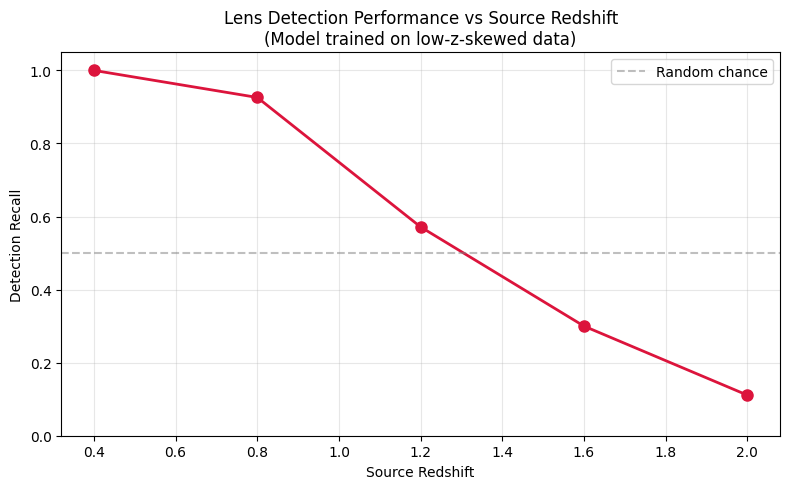

In [46]:
import matplotlib.pyplot as plt

bin_centers = [0.4, 0.8, 1.2, 1.6, 2.0]  # midpoints of your bins

plt.figure(figsize=(8,5))
plt.plot(bin_centers, bin_accuracy.values, marker='o', linewidth=2, markersize=8, color='crimson')
plt.xlabel('Source Redshift')
plt.ylabel('Detection Recall')
plt.title('Lens Detection Performance vs Source Redshift\n(Model trained on low-z-skewed data)')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance')
plt.legend()
plt.tight_layout()
plt.show()